In [424]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 

In [425]:
dataset = sns.load_dataset('titanic')

In [426]:
# save to csv
dataset.to_csv("titanic.csv",index=False)

### Part A — Profiling, cleaning, and the data story

In [427]:
df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [428]:
df.shape

(891, 15)

In [429]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [430]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [431]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

#### Percentage of missing values

In [432]:
# missing values with its percentages

missing_count = df.isna().sum()
missing_percent = (df.isna().mean()*100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count":missing_count,
    "Percentage (%)":missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Count"]>0]
missing_summary

,Missing Count,Percentage (%)
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [433]:
# drop deck column because it does not add any value to the with lot of missing values with >70%
df.drop(columns=['deck'],inplace=True)

In [434]:
# droppend null values as it only ha 0.22% of missing values
df.dropna(subset=['embarked','embark_town'],axis=0,inplace=True)

In [435]:
# fill the missing age column with median as missing percentage is only 19%
df['age'] = df['age'].fillna(df['age'].median())

In [436]:
df.isna().sum()


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

### Univariate analysis

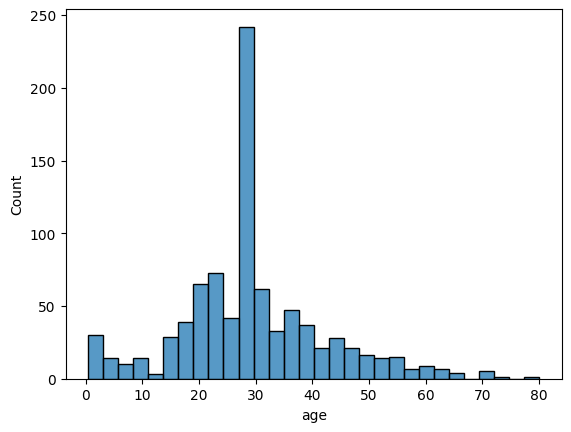

In [437]:
sns.histplot(data=df, x="age")
plt.show()

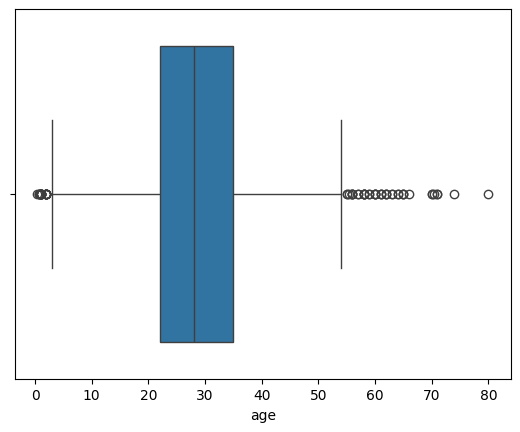

In [438]:
sns.boxplot(data=df,x="age")
plt.show()

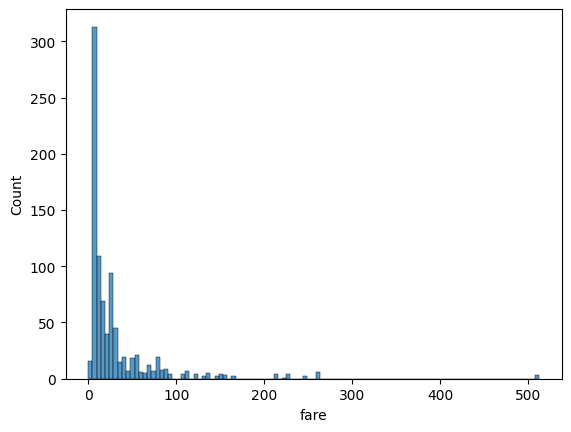

In [439]:
sns.histplot(data=df,x="fare")
plt.show()

<Axes: xlabel='fare'>

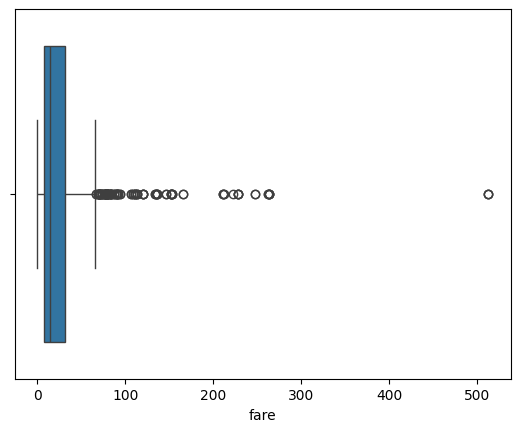

In [440]:
sns.boxplot(data=df,x='fare')

In [441]:
# outliers calculation of age and fare

required_columns = ['age','fare']

for col in required_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR_ = Q3-Q1

    lower_bound = Q1 - 1.5*IQR_
    upper_bound = Q3 + 1.5*IQR_

    print(f"IQR of {col} = {IQR_}")
    print(f"lower bound of {col} = {lower_bound} and upper bound of {col} = {upper_bound}")


    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"Number of outliers in {col} are {len(outliers)}")

IQR of age = 13.0
lower bound of age = 2.5 and upper bound of age = 54.5
Number of outliers in age are 65
IQR of fare = 23.1042
lower bound of fare = -26.7605 and upper bound of fare = 65.6563
Number of outliers in fare are 114


In [442]:
# mean median mode of fare column

mean_fare = df['fare'].mean()
median_fare = df['fare'].median()
mode_fare = df['fare'].mode().iloc[0]

print(f"Mean = {mean_fare}, Median = {median_fare}, Mode = {mode_fare}")

# here Mean > Median > Mode so this is right skew


Mean = 32.09668087739032, Median = 14.4542, Mode = 8.05


### Bivatiate analysis

In [443]:
# df['sex'] == 'female'
df[df["sex"] == "female"]["survived"].mean()*100
df[df["sex"] == "male"]["survived"].mean()*100

np.float64(18.890814558058924)

In [444]:
df['pclass'].unique()

array([3, 1, 2])

In [445]:
df[df["pclass"] == 1]["survived"].mean() * 100
df[df["pclass"] == 2]["survived"].mean() * 100
df[df["pclass"] == 3]["survived"].mean() * 100

np.float64(24.236252545824847)

In [446]:
# percentage of females from class 1 survived
print(f"Survival rate of female from pclass1 = {df[(df['sex'] == 'female') & (df['pclass'] == 1)]['survived'].mean()*100}")

# percentage of females from class 2 survived
print(f"Survival rate of female from pclass2 = {df[(df['sex'] == 'female') & (df['pclass'] == 2)]['survived'].mean()*100}")

# percentage of females from class 3 survived
print(f"Survival rate of female from pclass3 = {df[(df['sex'] == 'female') & (df['pclass'] == 3)]['survived'].mean()*100}")


# percentage of males from class 1 survived
print(f"Survival rate of male from pclass1 = {df[(df['sex'] == 'male') & (df['pclass'] == 1)]['survived'].mean()*100}")

# percentage of males from class 2 survived
print(f"Survival rate of male from pclass2 = {df[(df['sex'] == 'male') & (df['pclass'] == 2)]['survived'].mean()*100}")

# percentage of males from class 3 survived
print(f"Survival rate of male from pclass3 = {df[(df['sex'] == 'male') & (df['pclass'] == 3)]['survived'].mean()*100}")


print(f"Survival rate of pclass 1 or pclass 2 = {df[(df['pclass'] == 1) | (df['pclass'] == 2)]['survived'].mean()*100}")

Survival rate of female from pclass1 = 96.73913043478261
Survival rate of female from pclass2 = 92.10526315789474
Survival rate of female from pclass3 = 50.0
Survival rate of male from pclass1 = 36.885245901639344
Survival rate of male from pclass2 = 15.74074074074074
Survival rate of male from pclass3 = 13.544668587896252
Survival rate of pclass 1 or pclass 2 = 55.527638190954775


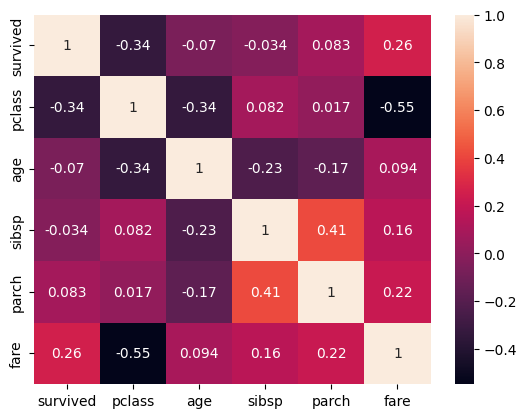

In [447]:
corr_df = df[[
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]]

corr_matrix = corr_df.corr()

# print(corr_matrix)
sns.heatmap(corr_matrix,annot=True)
plt.show()

In [448]:
# get the top 2 correlated columns

pairs_df = corr_matrix.stack().reset_index()

pairs_df.columns = ["feature1", "feature2", "correlation"]
pairs_df = pairs_df[pairs_df['feature1'] != pairs_df['feature2']]


columns = list(corr_matrix.columns)

# map the index for each column and check the duplicates
pairs_df = pairs_df[
    pairs_df["feature1"].map(columns.index) <
    pairs_df["feature2"].map(columns.index)
]

pairs_df['abs_correlation'] = pairs_df['correlation'].abs()

pairs_df = pairs_df.sort_values("abs_correlation",ascending=False)
top_2 = pairs_df.head(2)
top_2

,feature1,feature2,correlation,abs_correlation
11,pclass,fare,-0.548193,0.548193
22,sibsp,parch,0.414542,0.414542


### Summary about correlation
Pclass and fare has strongest negative correlation with value -0.548.
this says as the passenger class number increases from first class (1) to third class (3) the fare generally decreases.

Sibsp and parch have the stronges positive correlation of 0.415, indicating that passengers travelling with more siblings/spouses also tended to travel with more parents/children

### MultiVariate Analysis

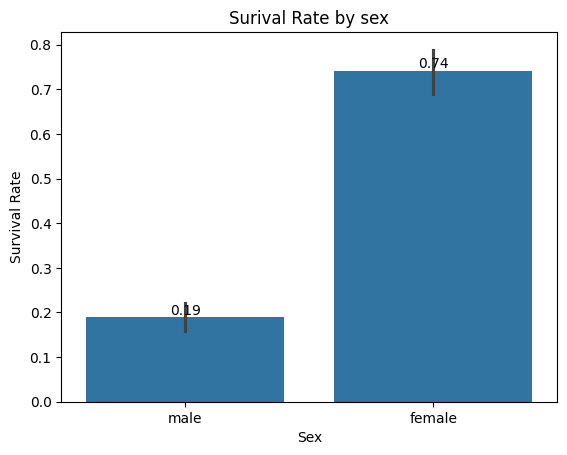

In [449]:
# survival rate vs sex

ax = sns.barplot(data=df,x='sex',y='survived',)
plt.title("Surival Rate by sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.show()

#### Survival rate vs Sex Graph Interpretation

- Female passengers(74%) survival rate is more than male passengers(19%). 
- This shows there is a large difference in survival outcome with sex, with female passengers mostly surviving

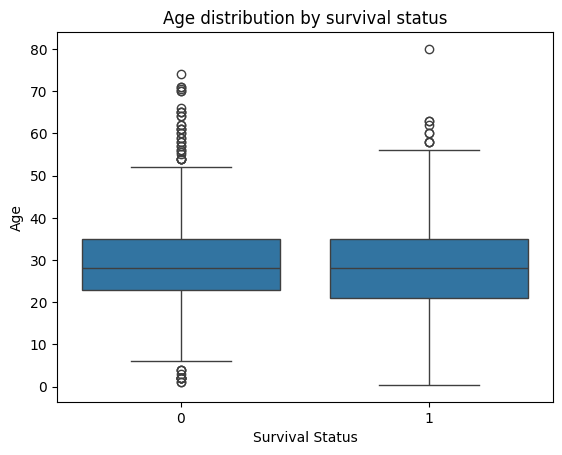

In [450]:
# survival rate vs age

sns.boxplot(data=df,x='survived',y='age')
plt.title("Age distribution by survival status")
plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.show()

#### Survival status vs Age Interpretation

- The median age of survivors and non-survivors is very similar, at around 28 years. 
- The age distributions also overlap considerably, suggesting that age alone does not show a strong difference between the two survival groups.
- Both groups contain age outliers, particularly among older passengers.

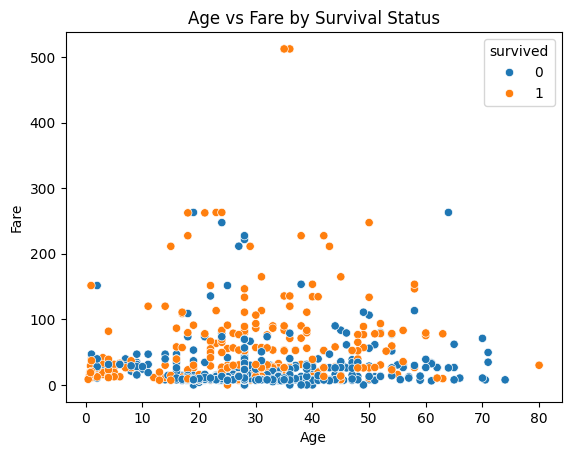

In [451]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival Status")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

#### Survival Status vs Age vs Fare Interpretation

- Survivors and non-survivors are spread across almost all age groups, so age does not show a clear difference in survival. 
- We can also see more survivors among passengers who paid higher fares. 
- This suggests that ticket fare/price may be more related to survival than age.

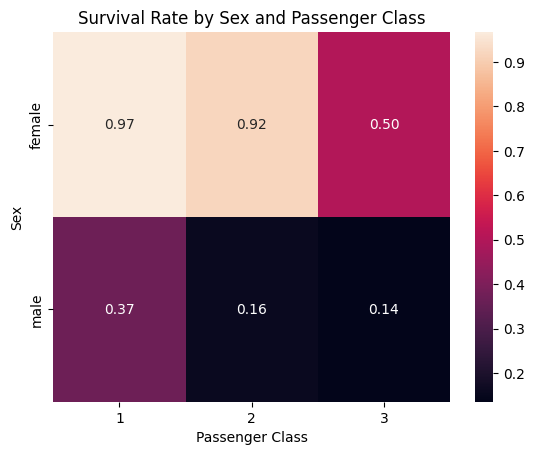

In [452]:
survival_table = df.pivot_table(
    values="survived",
    index="sex",
    columns="pclass",
    aggfunc="mean"
)

sns.heatmap(
    survival_table,
    annot=True,
    fmt=".2f"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Sex")
plt.show()

#### Survival Rate vs sex vs pclass

- Female passengers had a much higher survival rate than male passengers in every class. 
- First-class females had the highest survival rate at 97%, followed by second-class females at 92%. 
- Survival was much lower for males, especially in second and third class, showing that both sex and passenger class were strongly related to survival.

#### Before Standardization

In [453]:
df[["age", "fare"]].agg(["mean", "std"])

,age,fare
mean,29.315152,32.096681
std,12.984932,49.697504


In [454]:
scaled_df = df.copy()
req_cols = ["age","fare"]
for col in req_cols:
    scaled_df[col] = (
        scaled_df[col] - scaled_df[col].mean()
    ) / scaled_df[col].std()

#### After Standardization

In [455]:
scaled_df[["age", "fare"]].agg(["mean", "std"])

,age,fare
mean,2.797412e-16,1.358743e-16
std,1.000000e+00,1.000000e+00


After standardization, both age and fare have a mean approximately equal to 0 and a standard deviation of 1. 

#### Save the cleaned dataset as clean_titanic.csv for the modeling task (PART B)

In [456]:
df.to_csv("clean_titanic.csv", index=False)